## Depression Severity Classification and PHQ-8 Score Regression using Two-Level LSTM

This notebook implements and trains a two-level LSTM-based neural network (`ParticipantDepressionNet`) to classify depression severity (into 5 classes based on PHQ-8 scores) and regress the PHQ-8 score directly. The model processes pre-extracted facial feature windows from the DAIC-WOZ video dataset.

The key steps covered include:
- **Data Preparation**: Loading metadata, defining PHQ-8 severity classes, and preparing custom PyTorch `Dataset` and `DataLoader` for participant-level data.
- **Feature Scaling**: Using `StandardScaler` fitted on the training data to normalize facial features across windows.
- **Model Architecture**: Implementation of a `ParticipantDepressionNet` with a BiLSTM for per-window embedding and a causal LSTM for across-window participant-level representation.
- **Training**: Training the model using a combined loss of CrossEntropy for classification and Mean Squared Error for regression, with dynamic learning rate scheduling and early stopping.
- **Evaluation**: Comprehensive evaluation of the model's performance on the test set using classification metrics (accuracy, F1-score, confusion matrix, classification report) and regression metrics (MAE, RMSE, R2 score).
- **Visualization**: Plotting training history (loss, F1, RMSE) and the confusion matrix.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
BASE_DIR      = Path("/content/drive/MyDrive")
PROCESSED_DIR = BASE_DIR / "DAIC_WOZ_VIDEO_BRANCH" / "data" / "processed"
WINDOWS_DIR   = PROCESSED_DIR / "windows_processed"
NEW_PROC_DIR  = PROCESSED_DIR / "new_processed"

In [ ]:
FPS         = 30
WINDOW_SIZE = 300    # 10 sec @ 30fps
STRIDE      = 150    # 5 sec overlap
BATCH_SIZE  = 4      # participants per batch
NUM_EPOCHS  = 80
PATIENCE    = 20
LR          = 1e-4
ALPHA       = 0.02  # regression loss weight
DROP_FEATURES = ["frame", "timestamp", "confidence", "success"]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PROCESSED_DIR exists: {PROCESSED_DIR.exists()}")

Device: cuda
PROCESSED_DIR exists: True


In [ ]:
# @title
session_ids = [300,
 301,
 302,
 303,
 304,
 305,
 306,
 307,
 308,
 309,
 310,
 311,
 312,
 313,
 314,
 315,
 316,
 317,
 318,
 319,
 320,
 321,
 322,
 323,
 324,
 325,
 326,
 327,
 328,
 329,
 330,
 331,
 332,
 333,
 334,
 335,
 336,
 337,
 338,
 339,
 340,
 341,
 343,
 344,
 345,
 346,
 347,
 348,
 349,
 350,
 351,
 352,
 353,
 354,
 355,
 356,
 357,
 358,
 359,
 360,
 361,
 362,
 363,
 364,
 365,
 366,
 367,
 368,
 369,
 370,
 371,
 372,
 373,
 374,
 375,
 376,
 377,
 378,
 379,
 380,
 381,
 382,
 383,
 384,
 385,
 386,
 387,
 388,
 389,
 390,
 391,
 392,
 393,
 395,
 396,
 397,
 399,
 400,
 401,
 402,
 403,
 404,
 405,
 406,
 407,
 408,
 409,
 410,
 411,
 412,
 413,
 414,
 415,
 416,
 417,
 418,
 419,
 420,
 421,
 422,
 423,
 424,
 425,
 426,
 427,
 428,
 429,
 430,
 431,
 432,
 433,
 434,
 435,
 436,
 437,
 438,
 439,
 440,
 441,
 442,
 443,
 444,
 445,
 446,
 447,
 448,
 449,
 450,
 451,
 452,
 453,
 454,
 455,
 456,
 457,
 458,
 459,
 461,
 462,
 463,
 464,
 465,
 466,
 467,
 468,
 469,
 470,
 471,
 472,
 473,
 474,
 475,
 476,
 477,
 478,
 479,
 480,
 481,
 482,
 483,
 484,
 485,
 486,
 487,
 488,
 489,
 490,
 491,
 492,
 601,
 603,
 608,
 612,
 617,
 627,
 628,
 632,
 633,
 641,
 653,
 654,
 657,
 660,
 662,
 667,
 670,
 673,
 677,
 680,
 684,
 687,
 692,
 695,
 697,
 698,
 702,
 703,
 707,
 713]

In [ ]:
# label_df    = pd.read_csv(BASE_DIR / "edaic3.0" / "labels" / "Detailed_PHQ8_Labels.csv")
# session_ids = label_df["Participant_ID"].tolist()

In [ ]:
metadata_df = pd.read_csv(WINDOWS_DIR / "metadata.csv")

train_df = metadata_df[metadata_df["split"] == "train"].reset_index(drop=True)
val_df   = metadata_df[metadata_df["split"] == "val"].reset_index(drop=True)
test_df  = metadata_df[metadata_df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)} participants | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain labels:\n", train_df["binary_label"].value_counts())
print("\nVal labels:\n",   val_df["binary_label"].value_counts())
print("\nTest labels:\n",  test_df["binary_label"].value_counts())

Train: 131 participants | Val: 44 | Test: 44

Train labels:
 binary_label
0    92
1    39
Name: count, dtype: int64

Val labels:
 binary_label
0    31
1    13
Name: count, dtype: int64

Test labels:
 binary_label
0    31
1    13
Name: count, dtype: int64


In [ ]:
def phq_to_class(score):
    if score <= 4:
        return 0
    elif score <= 9:
        return 1
    elif score <= 14:
        return 2
    elif score <= 19:
        return 3
    else:
        return 4

metadata_df["severity_class"] = metadata_df["phq_score"].apply(phq_to_class)

In [ ]:
all_train_frames = []

for _, row in train_df.iterrows():

    windows = np.load(
        row["window_file"]
    )

    frames = windows.reshape(
        -1,
        windows.shape[-1]
    )

    all_train_frames.append(frames)

In [ ]:
print("Train frames shape:", len(all_train_frames))

Train frames shape: 131


In [ ]:
all_train_frames = np.concatenate(
    all_train_frames,
    axis=0
)

print(all_train_frames.shape)

(7309500, 49)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# scaler.fit(all_train_frames)

In [ ]:
for _, row in train_df.iterrows():
    windows = np.load(row["window_file"])
    frames  = windows.reshape(-1, windows.shape[-1])
    scaler.partial_fit(frames)
import gc
del frames, all_train_frames
gc.collect()

704

In [ ]:
import joblib

joblib.dump(
    scaler,
    PROCESSED_DIR/ "scaler.pkl"
)

['/content/drive/MyDrive/DAIC_WOZ_VIDEO_BRANCH/data/processed/scaler.pkl']

In [ ]:
import joblib
scaler = joblib.load(
    PROCESSED_DIR/ "scaler.pkl"
)

In [ ]:
class ParticipantDataset(Dataset):
    """
    One sample = one participant (all their windows).
    Scaler is applied here — val/test are transformed with train scaler,
    which is the correct way to avoid leakage.
    """
    def __init__(self, metadata_df, scaler):
        self.metadata = metadata_df.reset_index(drop=True)
        self.scaler   = scaler

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row      = self.metadata.iloc[idx]
        raw      = np.load(row["window_file"])  # (W, 300, 49)
        W, T, F  = raw.shape
        scaled   = self.scaler.transform(
            raw.reshape(-1, F), copy=False
        ).reshape(W, T, F).astype(np.float32, copy=False)
        return {
            "windows":        torch.from_numpy(scaled),
            "severity_class": torch.tensor(row["severity_class"], dtype=torch.long),
            # "binary_label":   torch.tensor(row["binary_label"], dtype=torch.long),
            "phq_score":      torch.tensor(row["phq_score"],    dtype=torch.float32),
            "participant_id": row["participant_id"]
        }


def participant_collate(batch):
    """
    Pads windows along the W (num_windows) dimension so variable-length
    participants can be batched. num_windows tracks the real lengths
    so padding is masked out in the model.
    """
    windows     = [x["windows"] for x in batch]                # list of (W_i, 300, 49)
    num_windows = torch.tensor([w.shape[0] for w in windows])  # (B,)
    padded      = pad_sequence(windows, batch_first=True)       # (B, W_max, 300, 49)
    return {
        "windows":        padded,
        "num_windows":    num_windows,
        # "binary_label":   torch.stack([x["binary_label"] for x in batch]),
        "severity_class": torch.stack([x["severity_class"] for x in batch]),
        "phq_score":      torch.stack([x["phq_score"]    for x in batch]),
        "participant_id": [x["participant_id"]            for x in batch]
    }


scaler = joblib.load(PROCESSED_DIR / "scaler.pkl")

# Ensure train_df, val_df, test_df have 'severity_class' column
# This is a workaround if these dataframes were created before 'severity_class' was added to metadata_df
if "severity_class" not in train_df.columns:
    train_df["severity_class"] = train_df["phq_score"].apply(phq_to_class)
if "severity_class" not in val_df.columns:
    val_df["severity_class"] = val_df["phq_score"].apply(phq_to_class)
if "severity_class" not in test_df.columns:
    test_df["severity_class"] = test_df["phq_score"].apply(phq_to_class)

train_dataset = ParticipantDataset(train_df, scaler)
val_dataset   = ParticipantDataset(val_df,   scaler)
test_dataset  = ParticipantDataset(test_df,  scaler)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=participant_collate,
    # num_workers=0,        # don't set too high — each worker copies RAM
    # pin_memory=False

)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=participant_collate
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=participant_collate
)

batch = next(iter(train_loader))
print("windows shape: ", batch["windows"].shape)     # (B, W_max, 300, 49)
print("num_windows:   ", batch["num_windows"])
print("severity_class:  ", batch["severity_class"])

windows shape:  torch.Size([4, 287, 300, 49])
num_windows:    tensor([286, 167, 121, 287])
severity_class:   tensor([0, 0, 1, 3])


In [ ]:
# class ParticipantDepressionNet(nn.Module):
#     """
#     Two-level architecture:
#       Level 1 — BiLSTM + attention pools each 10-sec window -> window embedding
#       Level 2 — Masked mean across VALID windows only -> participant embedding

#     Key fixes vs original:
#       - num_windows mask excludes zero-padded windows from the mean
#       - LayerNorm after shared linear for stable training
#       - 2-layer BiLSTM with dropout
#     """
#     def __init__(
#         self,
#         input_size=49,
#         hidden_size=64,
#         num_layers=2,
#         dropout=0.3
#     ):
#         super().__init__()

#         # --- Level 1: per-window encoder ---
#         self.window_encoder = nn.LSTM(
#             input_size=input_size,
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             batch_first=True,
#             dropout=dropout,
#             bidirectional=True
#         )
#         lstm_out_dim = hidden_size * 2  # 128
#         self.window_attention = nn.Linear(lstm_out_dim, 1)

#         # --- Level 2: participant classifier/regressor ---
#         self.shared = nn.Sequential(
#             nn.Linear(lstm_out_dim, 64),
#             nn.LayerNorm(64),
#             nn.ReLU(),
#             nn.Dropout(dropout)
#         )
#         self.classifier = nn.Linear(64, 2)
#         self.regressor  = nn.Linear(64, 1)




#     def encode_window(self, windows_flat):
#         """windows_flat: (B*W, T, F) -> (B*W, lstm_out_dim)"""
#         lstm_out, _ = self.window_encoder(windows_flat)          # (B*W, T, 128)
#         scores      = self.window_attention(lstm_out).squeeze(-1) # (B*W, T)
#         weights     = torch.softmax(scores, dim=1)                # (B*W, T)
#         embeddings  = (lstm_out * weights.unsqueeze(-1)).sum(dim=1) # (B*W, 128)
#         return embeddings

#     def forward(self, windows, num_windows):
#         """
#         windows:     (B, W_max, T, F)
#         num_windows: (B,)  — real window count per participant
#         """
#         B, W, T, F   = windows.shape
#         windows_flat = windows.reshape(B * W, T, F)
#         embeddings   = self.encode_window(windows_flat)  # (B*W, 128)
#         embeddings   = embeddings.reshape(B, W, -1)      # (B, W, 128)

#         # Mask out padding before averaging
#         mask = torch.zeros(B, W, 1, device=windows.device)
#         for i, n in enumerate(num_windows):
#             mask[i, :n] = 1.0

#         participant_emb = (
#             (embeddings * mask).sum(dim=1)
#             / mask.sum(dim=1).clamp(min=1)
#         )  # (B, 128)

#          # ---------------------------------------
#         packed_out, (h_n, _) = self.participant_encoder(packed)
#         out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
#         # out: (B, W_max, 64) — hidden state at every window step

#         # attention over the trajectory
#         scores  = self.traj_attention(out).squeeze(-1)          # (B, W_max)
#         mask    = (torch.arange(W)[None,:] >= num_windows[:,None]).to(windows.device)
#         scores  = scores.masked_fill(mask, -1e9)
#         weights = torch.softmax(scores, dim=1)                  # (B, W_max)
#         participant_emb = (out * weights.unsqueeze(-1)).sum(1)  # (B, 64)
#         # ---------------------------------------

#         shared = self.shared(participant_emb)
#         return {
#             "class_logits": self.classifier(shared),  # (B, 2)
#             "phq_score":    self.regressor(shared)    # (B, 1)
#         }


# # Shape test
# model = ParticipantDepressionNet().to(device)
# out   = model(
#     batch["windows"].to(device),
#     batch["num_windows"]
# )
# print("class_logits:", out["class_logits"].shape)
# print("phq_score:   ", out["phq_score"].shape)

In [ ]:
class ParticipantDepressionNet(nn.Module):
    def __init__(
        self,
        input_size   = 49,
        win_hidden   = 64,    # level 1 — within window
        part_hidden  = 64,    # level 2 — across windows
        num_layers   = 2,
        dropout      = 0.3
    ):
        super().__init__()

        # ── Level 1: per-window BiLSTM (same as before) ──────────────────
        self.window_encoder = nn.LSTM(
            input_size   = input_size,
            hidden_size  = win_hidden,
            num_layers   = num_layers,
            batch_first  = True,
            dropout      = dropout,
            bidirectional= True
        )
        win_out_dim = win_hidden * 2   # 128

        self.window_attention = nn.Linear(win_out_dim, 1)

        # ── Level 2: across-window LSTM (NEW) ────────────────────────────
        # takes the sequence of window embeddings as input
        # unidirectional — past windows can inform future, not vice versa
        self.participant_encoder = nn.LSTM(
            input_size  = win_out_dim,   # 128
            hidden_size = part_hidden,   # 64
            num_layers  = 1,
            batch_first = True,
            dropout     = 0.0,           # single layer, no dropout needed
            bidirectional = False        # causal — past → future only
        )

        # ── Level 3: classifier/regressor (same as before) ───────────────
        self.shared = nn.Sequential(
            nn.Linear(part_hidden, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(64, 5)
        self.regressor  = nn.Linear(64, 1)


    def encode_window(self, windows_flat):
        """(B*W, T, F) → (B*W, 128)  — unchanged from before"""
        lstm_out, _ = self.window_encoder(windows_flat)
        scores      = self.window_attention(lstm_out).squeeze(-1)
        weights     = torch.softmax(scores, dim=1)
        return (lstm_out * weights.unsqueeze(-1)).sum(dim=1)


    def forward(self, windows, num_windows):
        B, W, T, F = windows.shape

        # ── Level 1: encode each window independently ─────────────────
        windows_flat = windows.reshape(B * W, T, F)
        embeddings   = self.encode_window(windows_flat)   # (B*W, 128)
        embeddings   = embeddings.reshape(B, W, 128)      # (B, W, 128)

        # ── Level 2: run window embeddings through participant LSTM ───
        # pack so padded windows don't affect the hidden state
        packed = nn.utils.rnn.pack_padded_sequence(
            embeddings,
            num_windows.cpu(),
            batch_first  = True,
            enforce_sorted = False          # don't need to pre-sort
        )
        packed_out, (h_n, _) = self.participant_encoder(packed)

        # h_n is (1, B, 64) — the hidden state AFTER the last REAL window
        # this is your participant summary with full sequential context
        participant_emb = h_n.squeeze(0)   # (B, 64)

        # ── Level 3: classify/regress ──────────────────────────────────
        shared = self.shared(participant_emb)
        return {
            "class_logits": self.classifier(shared),   # (B, 2)
            "phq_score":    self.regressor(shared)     # (B, 1)
        }

In [ ]:
# Class weights computed from train participants only
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1,2,3,4]),
    y=train_df["severity_class"].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

cls_criterion = nn.CrossEntropyLoss(weight=class_weights)
reg_criterion = nn.MSELoss()

model     = ParticipantDepressionNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Class weights: tensor([0.4441, 0.7939, 1.4556, 1.6375, 5.2400], device='cuda:0')


In [ ]:
def train_one_epoch(model, loader, optimizer, device, alpha=ALPHA):
    model.train()
    total_loss = total_cls = total_reg = 0

    for batch in loader:
        windows       = batch["windows"].to(device)
        num_windows   = batch["num_windows"]
        # binary_labels = batch["binary_label"].to(device)
        labels = batch["severity_class"].to(device)
        phq_scores    = batch["phq_score"].to(device)

        optimizer.zero_grad()
        outputs  = model(windows, num_windows)

        # cls_loss = cls_criterion(outputs["class_logits"], binary_labels)
        cls_loss = cls_criterion(outputs["class_logits"], labels)
        reg_loss = reg_criterion(outputs["phq_score"].squeeze(1), phq_scores)
        loss     = cls_loss + alpha * reg_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_cls  += cls_loss.item()
        total_reg  += reg_loss.item()

    n = len(loader)
    return total_loss / n, total_cls / n, total_reg / n


def validate(model, loader, device, alpha=ALPHA):
    model.eval()
    total_loss   = 0
    all_preds    = []; all_labels   = []
    all_phq_pred = []; all_phq_true = []

    with torch.no_grad():
        for batch in loader:
            windows       = batch["windows"].to(device)
            num_windows   = batch["num_windows"]
            labels = batch["severity_class"].to(device)
            phq_scores    = batch["phq_score"].to(device)

            outputs  = model(windows, num_windows)
            cls_loss = cls_criterion(outputs["class_logits"], labels)
            reg_loss = reg_criterion(outputs["phq_score"].squeeze(1), phq_scores)
            total_loss += (cls_loss + alpha * reg_loss).item()

            preds = torch.argmax(outputs["class_logits"], dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_phq_pred.extend(outputs["phq_score"].squeeze(1).cpu().numpy())
            all_phq_true.extend(phq_scores.cpu().numpy())

    f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc  = accuracy_score(all_labels, all_preds)
    rmse = np.sqrt(mean_squared_error(all_phq_true, all_phq_pred))
    return total_loss / len(loader), acc, f1, rmse

In [ ]:
best_f1          = 0
patience_counter = 0
history          = []
batch_size       = BATCH_SIZE

print("=" * 65)
print(f"Device: {device}  |  Train: {len(train_dataset)} participants  |  Val: {len(val_dataset)}")
print(f"Batch: {BATCH_SIZE}  |  LR: {LR}  |  Epochs: {NUM_EPOCHS}  |  Patience: {PATIENCE}")
print("=" * 65)

for epoch in range(NUM_EPOCHS):

    tr_loss, tr_cls, tr_reg = train_one_epoch(
        model, train_loader, optimizer, device
    )
    val_loss, val_acc, val_f1, val_rmse = validate(
        model, val_loader, device
    )
    scheduler.step()

    history.append({
        "epoch":      epoch + 1,
        "train_loss": tr_loss,
        "val_loss":   val_loss,
        "val_acc":    val_acc,
        "val_f1":     val_f1,
        "val_rmse":   val_rmse
    })

    print(
        f"Epoch {epoch+1:03d} | "
        f"TrLoss={tr_loss:.4f} (cls={tr_cls:.4f} reg={tr_reg:.4f}) | "
        f"ValLoss={val_loss:.4f} | "
        f"Acc={val_acc:.4f} | "
        f"F1(macro)={val_f1:.4f} | "
        f"RMSE={val_rmse:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), "best_participant_model.pt")
        print(f"  New best F1={best_f1:.4f} — model saved")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

print(f"\nBest val macro-F1: {best_f1:.4f}")

Device: cuda  |  Train: 131 participants  |  Val: 44
Batch: 4  |  LR: 0.0001  |  Epochs: 80  |  Patience: 20
Epoch 001 | TrLoss=3.1789 (cls=1.6017 reg=78.8613) | ValLoss=2.5901 | Acc=0.5227 | F1(macro)=0.1728 | RMSE=7.3076
  New best F1=0.1728 — model saved
Epoch 002 | TrLoss=3.0632 (cls=1.5698 reg=74.6670) | ValLoss=2.5127 | Acc=0.5455 | F1(macro)=0.1771 | RMSE=7.0550
  New best F1=0.1771 — model saved
Epoch 003 | TrLoss=2.9452 (cls=1.5713 reg=68.6940) | ValLoss=2.4340 | Acc=0.5909 | F1(macro)=0.1834 | RMSE=6.8037
  New best F1=0.1834 — model saved
Epoch 004 | TrLoss=2.8579 (cls=1.5611 reg=64.8405) | ValLoss=2.3807 | Acc=0.5682 | F1(macro)=0.1818 | RMSE=6.5737
  No improvement (1/20)
Epoch 005 | TrLoss=2.7551 (cls=1.5267 reg=61.4222) | ValLoss=2.3608 | Acc=0.5909 | F1(macro)=0.2190 | RMSE=6.4294
  New best F1=0.2190 — model saved
Epoch 006 | TrLoss=2.7739 (cls=1.5515 reg=61.1218) | ValLoss=2.3256 | Acc=0.4091 | F1(macro)=0.1719 | RMSE=6.3208
  No improvement (1/20)
Epoch 007 | TrLoss=

KeyboardInterrupt: 

In [ ]:
SAVE_DIR = BASE_DIR / "DAIC_WOZ_VIDEO_BRANCH" / "results" / "models"

In [ ]:
# # full inference bundle — one file has everything
# BUNDLE_PATH = SAVE_DIR / "_4.0_2layer_lstm_video.pt"

# torch.save({
#     # model
#     "model_state_dict":  model.state_dict(),
#     "model_config": {
#         "input_size":  49,
#         "hidden_size": 64,
#         "num_layers":  2,
#         "dropout":     0.3
#     },
#     # scaler — embed directly so inference needs no extra files
#     "scaler_mean":   torch.tensor(scaler.mean_,   dtype=torch.float32),
#     "scaler_scale":  torch.tensor(scaler.scale_,  dtype=torch.float32),
#     # training outcome
#     "best_f1":       best_f1,
#     "history":       history,
#     "label_map":     {0: "non-depressed", 1: "depressed"}
# }, BUNDLE_PATH)

# print(f"\nInference bundle saved → {BUNDLE_PATH}")

In [ ]:
# bundle = torch.load(BUNDLE_PATH, map_location=device, weights_only=False)

# # reconstruct model
# cfg   = bundle["model_config"]

# # Adapt the config for the current model's __init__ signature
# adapted_cfg = {
#     "input_size": cfg["input_size"],
#     "win_hidden": cfg["hidden_size"],  # Map old hidden_size to new win_hidden
#     "part_hidden": cfg["hidden_size"], # Map old hidden_size to new part_hidden
#     "num_layers": cfg["num_layers"],
#     "dropout": cfg["dropout"]
# }
# model = ParticipantDepressionNet(**adapted_cfg).to(device)
# model.load_state_dict(bundle["model_state_dict"])
# model.eval()

# # reconstruct scaler
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# scaler         = StandardScaler()
# scaler.mean_   = bundle["scaler_mean"].cpu().numpy()
# scaler.scale_  = bundle["scaler_scale"].cpu().numpy()
# scaler.var_    = scaler.scale_ ** 2
# scaler.n_features_in_ = 49

# print(f"Loaded model — best val F1: {bundle['best_f1']:.4f}")

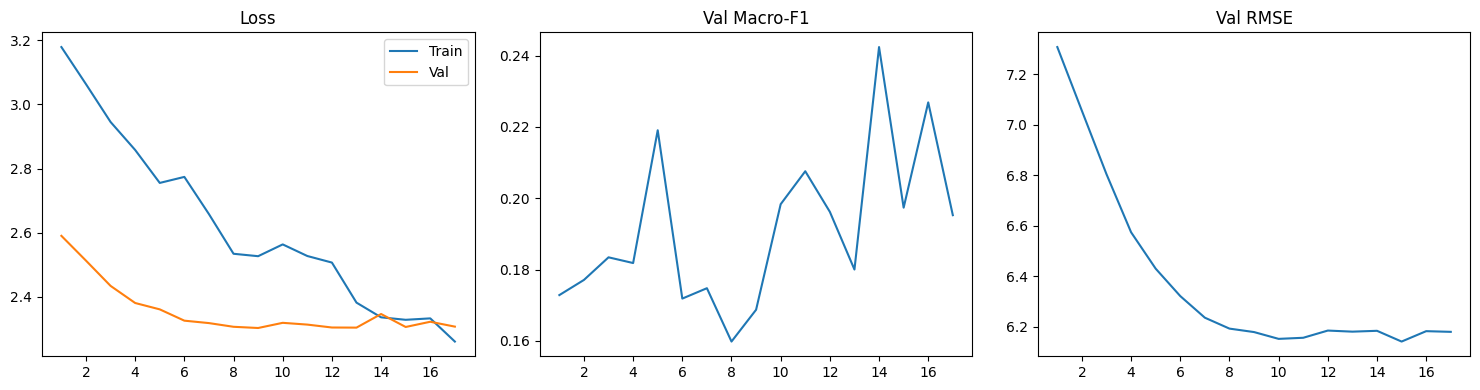

In [ ]:
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist["epoch"], hist["train_loss"], label="Train")
axes[0].plot(hist["epoch"], hist["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(hist["epoch"], hist["val_f1"])
axes[1].set_title("Val Macro-F1")

axes[2].plot(hist["epoch"], hist["val_rmse"])
axes[2].set_title("Val RMSE")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    all_cls_preds  = []; all_cls_labels = []
    all_phq_preds  = []; all_phq_labels = []

    with torch.no_grad():
        for batch in loader:
            windows       = batch["windows"].to(device)
            num_windows   = batch["num_windows"]
            severity_class = batch["severity_class"].to(device)
            phq_scores    = batch["phq_score"].to(device)

            outputs   = model(windows, num_windows)
            cls_preds = torch.argmax(outputs["class_logits"], dim=1)

            all_cls_preds.extend(cls_preds.cpu().numpy())
            all_cls_labels.extend(severity_class.cpu().numpy())
            all_phq_preds.extend(outputs["phq_score"].squeeze(1).cpu().numpy())
            all_phq_labels.extend(phq_scores.cpu().numpy())

    return {
        "accuracy":         accuracy_score(all_cls_labels, all_cls_preds),
        "precision":        precision_score(all_cls_labels, all_cls_preds, average="macro", zero_division=0),
        "recall":           recall_score(all_cls_labels, all_cls_preds,    average="macro", zero_division=0),
        "f1":               f1_score(all_cls_labels, all_cls_preds,        average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(all_cls_labels, all_cls_preds),
        "mae":              mean_absolute_error(all_phq_labels, all_phq_preds),
        "rmse":             np.sqrt(mean_squared_error(all_phq_labels, all_phq_preds)),
        "r2":               r2_score(all_phq_labels, all_phq_preds),
        "all_phq_preds":    all_phq_preds,
        "all_phq_labels":   all_phq_labels,
        "all_preds":        all_cls_preds,
        "all_labels":       all_cls_labels
    }


model.load_state_dict(torch.load("best_participant_model.pt", map_location=device))
model.to(device)

test_metrics = evaluate(model, test_loader, device)

# Make all_labels and all_preds available globally for subsequent cells
all_labels = test_metrics["all_labels"]
all_preds  = test_metrics["all_preds"]

print("\n" + "=" * 50)
print("TEST RESULTS  (participant-level)")
print("=" * 50)
for k, v in test_metrics.items():
    if k not in ["confusion_matrix", "all_phq_preds", "all_phq_labels", "all_preds", "all_labels"]:
        print(f"{k:<15}: {v:.4f}")
print("\nConfusion Matrix:")
# Use the confusion matrix directly from test_metrics
cm = test_metrics["confusion_matrix"]
print(cm)



TEST RESULTS  (participant-level)
accuracy       : 0.2955
precision      : 0.1763
recall         : 0.1781
f1             : 0.1734
mae            : 5.4934
rmse           : 7.4283
r2             : -0.4953

Confusion Matrix:
[[9 8 1 1 0]
 [6 3 2 1 0]
 [2 3 1 0 0]
 [2 3 0 0 0]
 [0 2 0 0 0]]


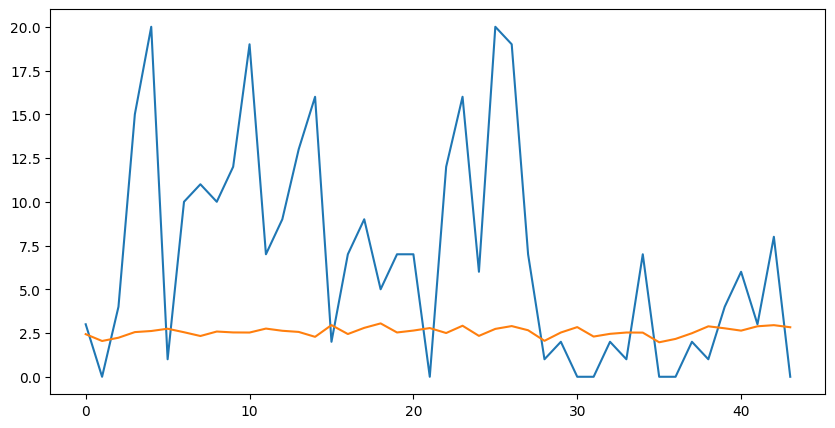

In [ ]:
# plot of true phq_score and predicted phq_score
plt.figure(figsize=(10, 5))
# plt.scatter(test_metrics["all_phq_labels"], test_metrics["all_phq_preds"])
# plt.plot(test_metrics["all_phq_labels"], test_metrics["all_phq_preds"])
plt.plot(test_metrics["all_phq_labels"])
plt.plot(test_metrics["all_phq_preds"])

In [ ]:
from sklearn.metrics import classification_report

class_names = [
    "Minimal",
    "Mild",
    "Moderate",
    "Moderately Severe",
    "Severe"
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)

                   precision    recall  f1-score   support

          Minimal     0.4737    0.4737    0.4737        19
             Mild     0.1579    0.2500    0.1935        12
         Moderate     0.2500    0.1667    0.2000         6
Moderately Severe     0.0000    0.0000    0.0000         5
           Severe     0.0000    0.0000    0.0000         2

         accuracy                         0.2955        44
        macro avg     0.1763    0.1781    0.1734        44
     weighted avg     0.2817    0.2955    0.2846        44



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = \
    precision_recall_fscore_support(
        all_labels,
        all_preds,
        labels=[0,1,2,3,4]
    )

for i, name in enumerate(class_names):
    print(f"\n{name}")
    print(f" Precision: {precision[i]:.4f}")
    print(f" Recall:    {recall[i]:.4f}")
    print(f" F1:        {f1[i]:.4f}")
    print(f" Support:   {support[i]}")


Minimal
 Precision: 0.4737
 Recall:    0.4737
 F1:        0.4737
 Support:   19

Mild
 Precision: 0.1579
 Recall:    0.2500
 F1:        0.1935
 Support:   12

Moderate
 Precision: 0.2500
 Recall:    0.1667
 F1:        0.2000
 Support:   6

Moderately Severe
 Precision: 0.0000
 Recall:    0.0000
 F1:        0.0000
 Support:   5

Severe
 Precision: 0.0000
 Recall:    0.0000
 F1:        0.0000
 Support:   2


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


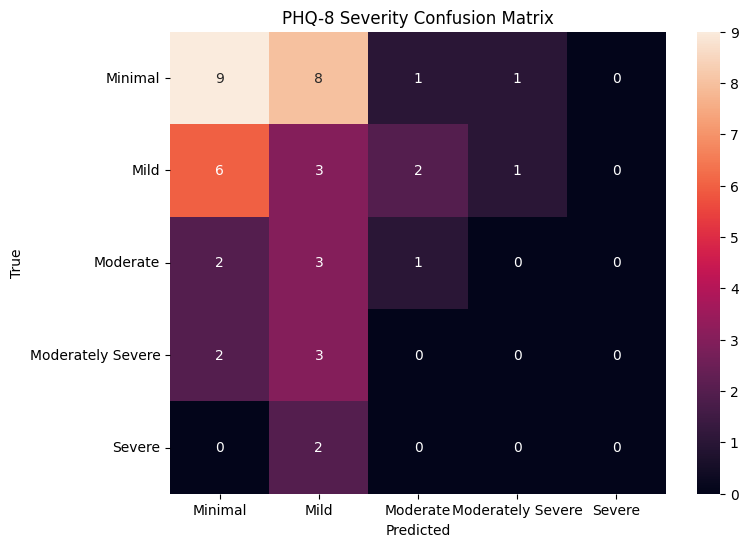

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=[0,1,2,3,4]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("PHQ-8 Severity Confusion Matrix")
plt.show()

In [ ]:
import numpy as np

class_acc = cm.diagonal() / cm.sum(axis=1)

for i, name in enumerate(class_names):
    print(f"{name}: {class_acc[i]:.4f}")

Minimal: 0.4737
Mild: 0.2500
Moderate: 0.1667
Moderately Severe: 0.0000
Severe: 0.0000


In [ ]:
import numpy as np

error_distance = np.abs(
    np.array(all_labels) -
    np.array(all_preds)
)

print("Mean Severity Error:",
      error_distance.mean())

Mean Severity Error: 1.0909090909090908
